# Exploratory Data Analysis (EDA)

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys

In [2]:
# ── Add project root to path ─────────────────────
PROJECT_ROOT = os.getcwd()
sys.path.append(PROJECT_ROOT)

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_PATH  = os.path.join("../data", "quora_question_pair_final.csv")
FIG_DIR    = "../notebooks/eda_figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save(name):
    path = f"{FIG_DIR}/{name}.png"
    plt.savefig(path, bbox_inches="tight", dpi=130)
    print(f"  💾 saved → {path}")

In [3]:
# ------------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)

# ------------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------------

print(f"Dataset Shape      : {df.shape}")
print(f"Number of Rows     : {df.shape[0]:,}")
print(f"Number of Columns  : {df.shape[1]}")

df.head()

Dataset Shape      : (404287, 28)
Number of Rows     : 404,287
Number of Columns  : 28


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.916659,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,0.699993,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.399996,0.0,1.0,4.0,12.0,0.169492,54,53,66,66
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,...,0.000000,0.0,0.0,1.0,11.5,0.040000,36,39,37,36
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,...,0.571420,0.0,1.0,6.0,10.0,0.153846,46,55,47,67


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404287 entries, 0 to 404286
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    404287 non-null  int64  
 1   qid1                  404287 non-null  int64  
 2   qid2                  404287 non-null  int64  
 3   question1             404272 non-null  object 
 4   question2             404278 non-null  object 
 5   is_duplicate          404287 non-null  int64  
 6   q1_len                404287 non-null  int64  
 7   q2_len                404287 non-null  int64  
 8   q1_num_words          404287 non-null  int64  
 9   q2_num_words          404287 non-null  int64  
 10  word_common           404287 non-null  int64  
 11  word_total            404287 non-null  int64  
 12  word_share            404287 non-null  float64
 13  cwc_min               404287 non-null  float64
 14  cwc_max               404287 non-null  float64
 15  

### Checking Null Values

In [5]:
df.isnull().sum()

id                       0
qid1                     0
qid2                     0
question1               15
question2                9
is_duplicate             0
q1_len                   0
q2_len                   0
q1_num_words             0
q2_num_words             0
word_common              0
word_total               0
word_share               0
cwc_min                  0
cwc_max                  0
csc_min                  0
csc_max                  0
ctc_min                  0
ctc_max                  0
last_word_eq             0
first_word_eq            0
abs_len_diff             0
mean_len                 0
longest_substr_ratio     0
fuzz_ratio               0
fuzz_partial_ratio       0
token_sort_ratio         0
token_set_ratio          0
dtype: int64

In [6]:
df.dropna(inplace=True)

### Checking Duplicate rows

In [7]:
df.duplicated().sum()

np.int64(0)

## Distribution of Target Variable

C:\Users\DELL\AppData\Local\Temp\ipykernel_6268\3248891698.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Non-Duplicate', 'Duplicate'])


  💾 saved → ../notebooks/eda_figures/01_Target_Distribution.png


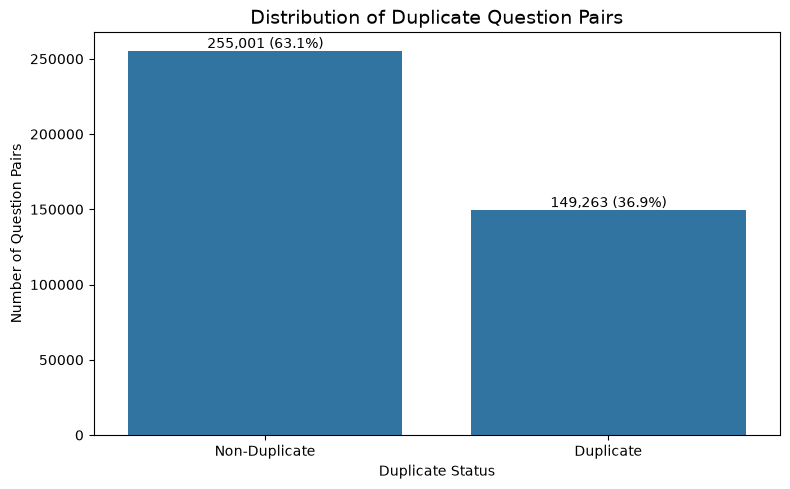

In [9]:
# Count values
counts = df['is_duplicate'].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x='is_duplicate',
    data=df
)

plt.title('Distribution of Duplicate Question Pairs', fontsize=14)
plt.xlabel('Duplicate Status')
plt.ylabel('Number of Question Pairs')

# Custom labels
ax.set_xticklabels(['Non-Duplicate', 'Duplicate'])

# Add counts and percentages
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f'{count:,} ({percentage:.1f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
save(name='01_Target_Distribution')
plt.show()

In [10]:
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())

total_unique_questions = qid.nunique()
repeated_questions = (qid.value_counts() > 1).sum()

print(f"Total Unique Questions      : {total_unique_questions:,}")
print(f"Repeated Questions          : {repeated_questions:,}")
print(f"Percentage Repeated         : {(repeated_questions/total_unique_questions)*100:.2f}%")


Total Unique Questions      : 537,898
Repeated Questions          : 111,768
Percentage Repeated         : 20.78%


  💾 saved → ../notebooks/eda_figures/02_Question_Frequencies.png


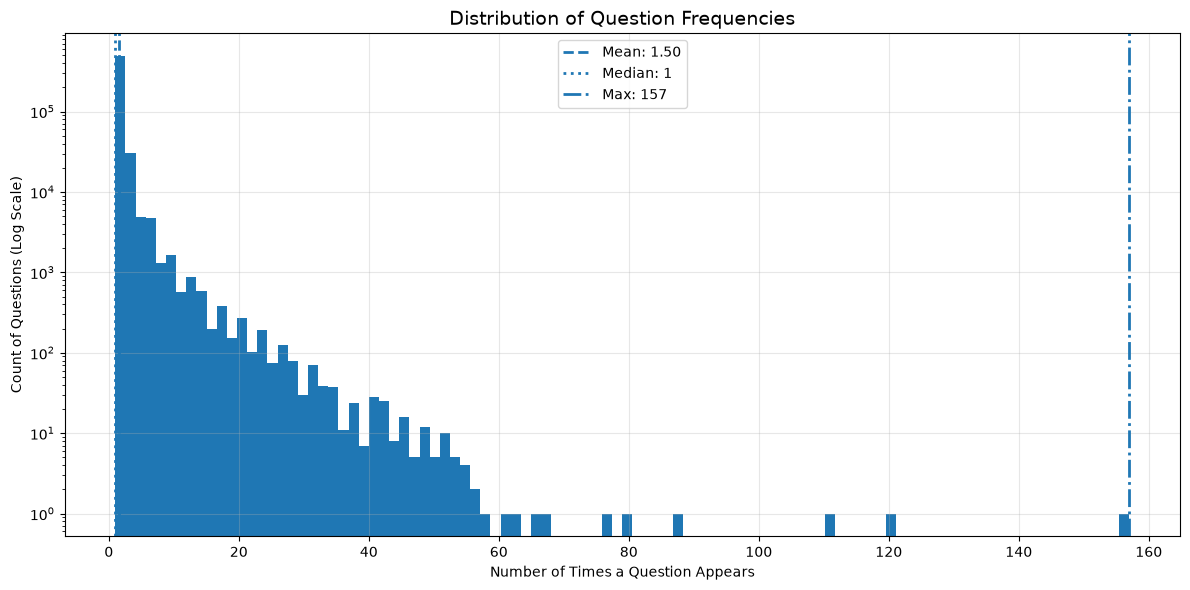

In [11]:
question_freq = qid.value_counts().values

plt.figure(figsize=(12, 6))

plt.hist(question_freq, bins=100)

plt.yscale('log')

plt.title('Distribution of Question Frequencies', fontsize=14)
plt.xlabel('Number of Times a Question Appears')
plt.ylabel('Count of Questions (Log Scale)')

plt.axvline(
    np.mean(question_freq),
    linestyle='--',
    linewidth=2,
    label=f'Mean: {np.mean(question_freq):.2f}'
)
plt.axvline(
    np.median(question_freq),
    linestyle=':',
    linewidth=2,
    label=f'Median: {np.median(question_freq):.0f}'
)
plt.axvline(
    max(question_freq),
    linestyle='-.',
    linewidth=2,
    label=f'Max: {max(question_freq):.0f}'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
save(name='02_Question_Frequencies')
plt.show()

### Questions length

  💾 saved → ../notebooks/eda_figures/03_Distribution_of_q1_len.png
  💾 saved → ../notebooks/eda_figures/04_Distribution_of_q2_len.png


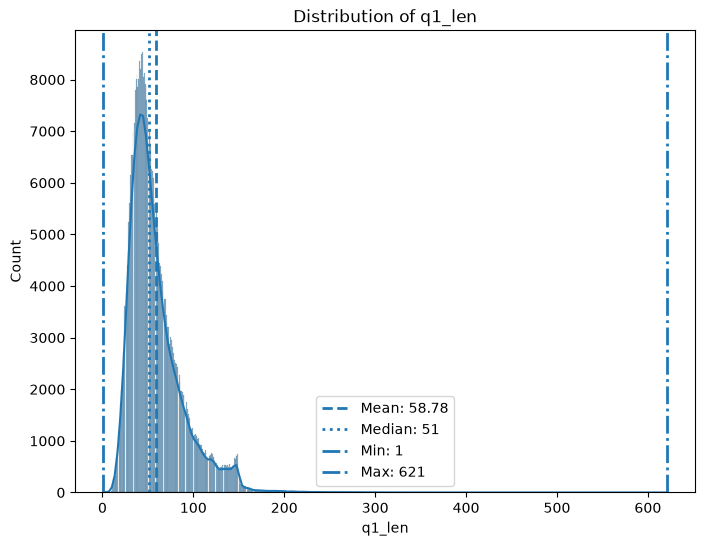

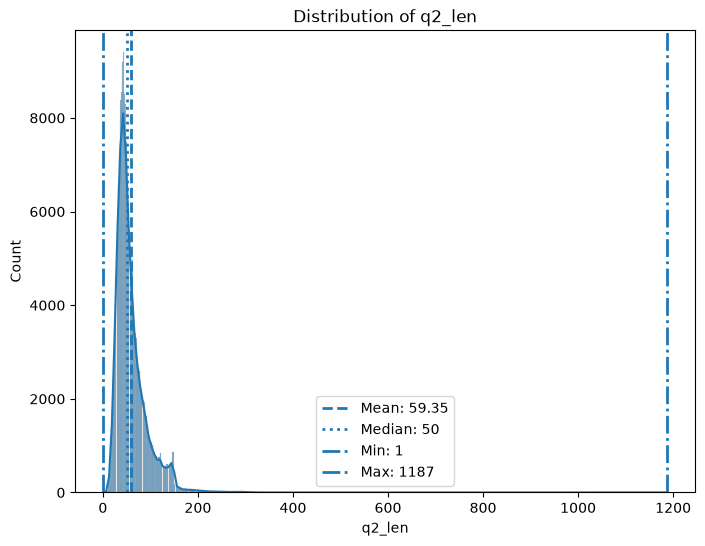

In [13]:
for i, col in enumerate(['q1_len', 'q2_len']):

    plt.figure(figsize=(8,6))
    
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    
    plt.axvline(
        np.mean(df[col]),
        linestyle='--',
        linewidth=2,
        label=f'Mean: {np.mean(df[col]):.2f}'
    )
    plt.axvline(
        np.median(df[col]),
        linestyle=':',
        linewidth=2,
        label=f'Median: {np.median(df[col]):.0f}'
    )
    
    min_length = df[col].min()
    max_length = df[col].max()
    plt.axvline(
        min_length,
        linestyle='-.',
        linewidth=2,
        label=f'Min: {min_length}'
    )

    plt.axvline(
        max_length,
        linestyle='-.',
        linewidth=2,
        label=f'Max: {max_length}'
    )
    save(name=f'0{i+3}_Distribution_of_{col}')
    plt.legend()

### Number of words in questions

  💾 saved → ../notebooks/eda_figures/05_Distribution_of_q1_num_words.png
  💾 saved → ../notebooks/eda_figures/06_Distribution_of_q2_num_words.png


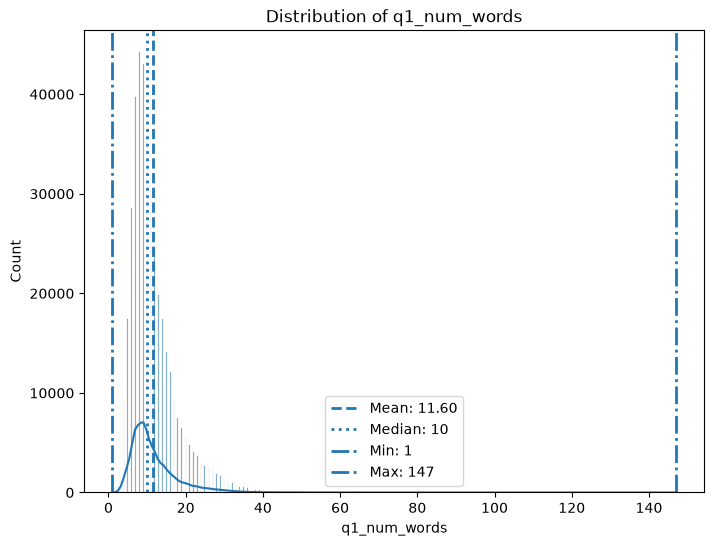

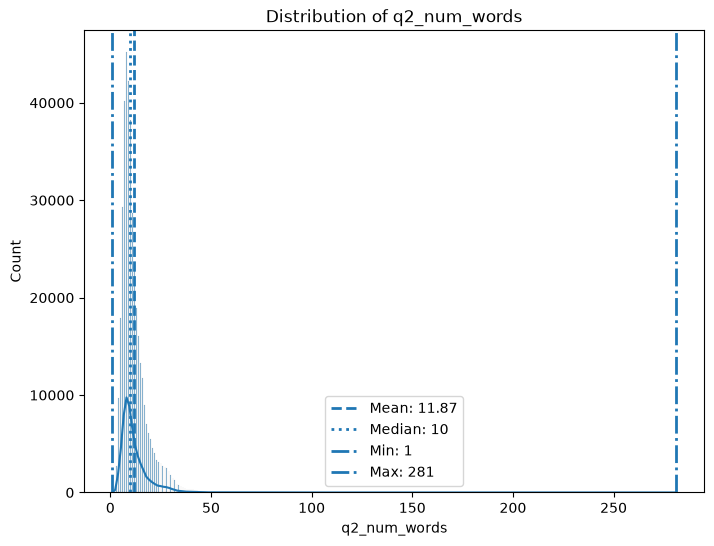

In [15]:
for i, col in enumerate(['q1_num_words', 'q2_num_words']):

    plt.figure(figsize=(8,6))
    
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.axvline(
        np.mean(df[col]),
        linestyle='--',
        linewidth=2,
        label=f'Mean: {np.mean(df[col]):.2f}'
    )
    plt.axvline(
        np.median(df[col]),
        linestyle=':',
        linewidth=2,
        label=f'Median: {np.median(df[col]):.0f}'
    )
    
    min_length = df[col].min()
    max_length = df[col].max()
    plt.axvline(
        min_length,
        linestyle='-.',
        linewidth=2,
        label=f'Min: {min_length}'
    )

    plt.axvline(
        max_length,
        linestyle='-.',
        linewidth=2,
        label=f'Max: {max_length}'
    )

    plt.legend()
    save(name=f'0{i+5}_Distribution_of_{col}')

### Common Words, Total Words and Share Words in both questions

  💾 saved → ../notebooks/eda_figures/07_Distribution_of_word_common.png


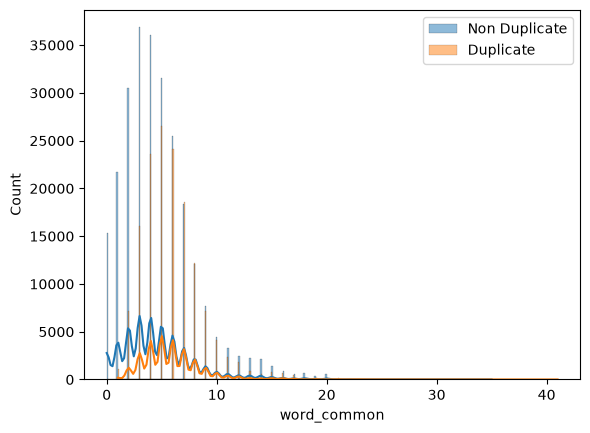

  💾 saved → ../notebooks/eda_figures/08_Distribution_of_word_total.png


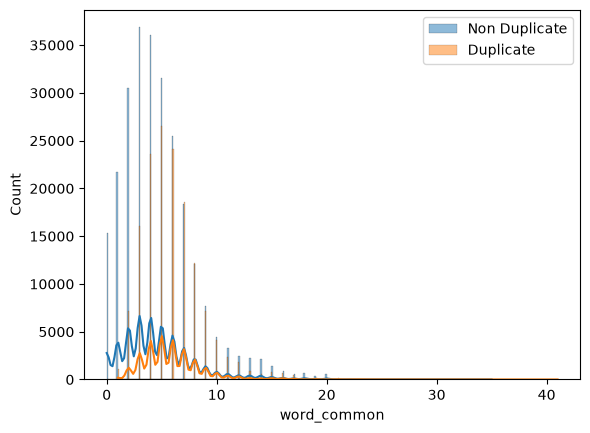

  💾 saved → ../notebooks/eda_figures/09_Distribution_of_word_share.png


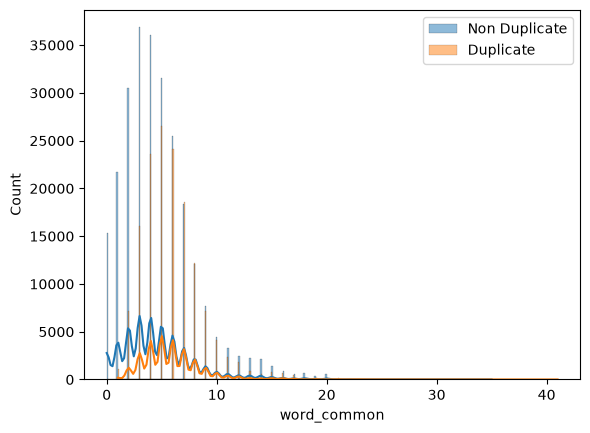

In [ ]:
for i, col in enumerate(['word_common', 'word_total', 'word_share']):
    sns.histplot(
        df[df['is_duplicate'] == 0][col],
        kde=True,
        label='Non Duplicate'
    )

    sns.histplot(
        df[df['is_duplicate'] == 1][col],
        kde=True,
        label='Duplicate'
    )

    plt.legend()
    save(name=f'0{i+7}_Distribution_of_{col}')
    plt.show()

### Pairplots of advanced features

  💾 saved → ../notebooks/eda_figures/11_max_token_feature_pairplot.png


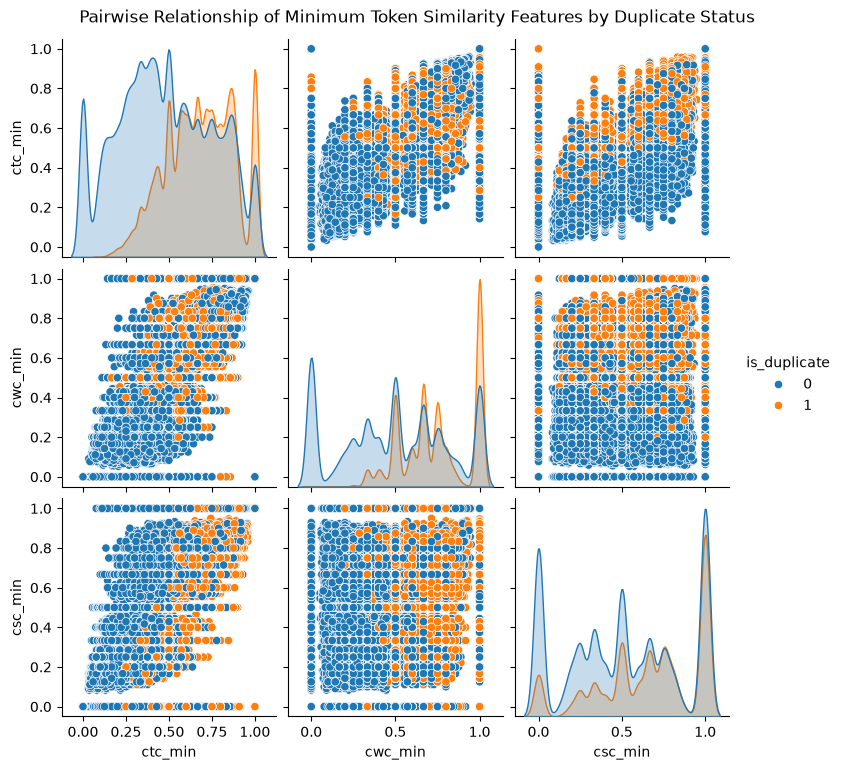

In [18]:
sns.pairplot(
    df[['ctc_min','cwc_min','csc_min','is_duplicate']],
    hue='is_duplicate'
)

plt.suptitle(
    'Pairwise Relationship of Minimum Token Similarity Features by Duplicate Status',
    y=1.02
)

save(name='10_min_token_feature_pairplot')

In [ ]:
sns.pairplot(
    df[['ctc_max','cwc_max','csc_max','is_duplicate']], 
    hue='is_duplicate'
)

plt.suptitle(
    'Pairwise Relationship of Maximum Token Similarity Features by Duplicate Status',
    y=1.02
)

save(name='11_max_token_feature_pairplot')

In [1]:
g = sns.pairplot(
    df[['last_word_eq', 'first_word_eq', 'is_duplicate']],
    hue='is_duplicate'
)

plt.suptitle(
    'Pairwise Relationship Between First/Last Word Matching and Duplicate Status',
    y=1.02
)

save(name='12_word_boundary_match_pairplot')

NameError: name 'sns' is not defined

In [ ]:
sns.pairplot(
    df[['mean_len','abs_len_diff','longest_substr_ratio','is_duplicate']], 
    hue='is_duplicate'
)

plt.suptitle(
    'Pairwise Relationship of Length and Substring Similarity Features by Duplicate Status',
    y=1.02
)

save(name='13_length_substring_feature_pairplot')

In [ ]:
sns.pairplot(
    df[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio','is_duplicate']], 
    hue='is_duplicate'
)

plt.suptitle(
    'Pairwise Relationship of Fuzzy String Matching Features by Duplicate Status',
    y=1.02
)

save(name='14_fuzzy_matching_feature_pairplot')